**Projet Fouille des données**

*Réalisé par:*
> Chaabane Boussadia & Raed Bettaher [IGL4]

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/chethuhn/network-intrusion-dataset


## Le Pipeline de notre Projet  :

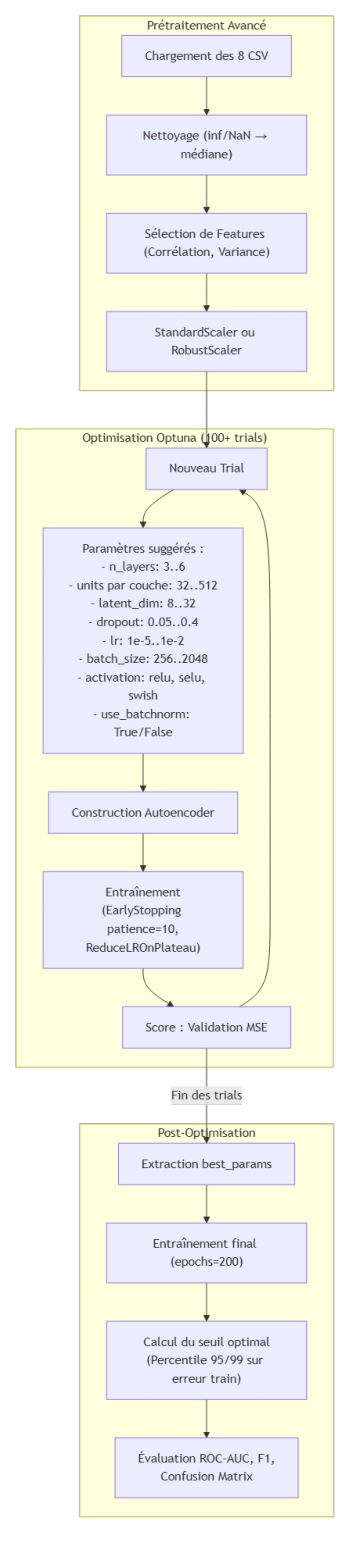

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('/kaggle/input/datasets/chaabaneboussadia/pipeline-imgs/architecture_ideale_2.png')

plt.figure(figsize=(25,20))  # 👈 augmente la taille ici
plt.imshow(img)
plt.axis('off')
plt.show()

Cette cellule télécharge le dataset **Network Intrusion** depuis Kaggle et confirme le chemin local obtenu. Le message affiché valide que la source de données est accessible et prête pour les étapes suivantes de copie, fusion et prétraitement.

**La référence vers le dataset**
*https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset*

In [3]:
import os
import shutil

source_path = path  # your dataset download location
destination_path = '/kaggle/working/dataset'  # ✅ writable directory

# Remove existing content if it exists
if os.path.exists(destination_path):
    shutil.rmtree(destination_path)

# Create the destination directory
os.makedirs(destination_path, exist_ok=True)

# Copy dataset to writable destination
for item in os.listdir(source_path):
    s = os.path.join(source_path, item)
    d = os.path.join(destination_path, item)
    if os.path.isdir(s):
        shutil.copytree(s, d, dirs_exist_ok=True)
    else:
        shutil.copy2(s, d)

print(f"Content of {source_path} copied to {destination_path}")

# Verify contents
print(f"\nContent of {destination_path} after copy:")
for dirname, _, filenames in os.walk(destination_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Content of /kaggle/input/datasets/chethuhn/network-intrusion-dataset copied to /kaggle/working/dataset

Content of /kaggle/working/dataset after copy:
/kaggle/working/dataset/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
/kaggle/working/dataset/Tuesday-WorkingHours.pcap_ISCX.csv
/kaggle/working/dataset/Wednesday-workingHours.pcap_ISCX.csv
/kaggle/working/dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
/kaggle/working/dataset/Friday-WorkingHours-Morning.pcap_ISCX.csv
/kaggle/working/dataset/Monday-WorkingHours.pcap_ISCX.csv
/kaggle/working/dataset/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
/kaggle/working/dataset/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv


### Interprétation du résultat
Le contenu du dataset a été recopié vers un dossier de travail écrivable (`/kaggle/working/dataset`). L’affichage des fichiers confirme que les CSV sont bien présents, ce qui sécurise la suite du pipeline (lecture multi-fichiers et concaténation).

=> Les fichers CSV sont les suivants :

* /kaggle/working/dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
* /kaggle/working/dataset/Tuesday-WorkingHours.pcap_ISCX.csv
* /kaggle/working/dataset/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
* /kaggle/working/dataset/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
* /kaggle/working/dataset/Wednesday-workingHours.pcap_ISCX.csv
* /kaggle/working/dataset/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
* /kaggle/working/dataset/Monday-WorkingHours.pcap_ISCX.csv
* /kaggle/working/dataset/Friday-WorkingHours-Morning.pcap_ISCX.csv

*Importation des modules nécessaires pour le projet:*

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image
import os, datetime
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, precision_recall_curve, average_precision_score, roc_auc_score
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
from sklearn.cluster import KMeans

from tensorflow.keras import layers, models, callbacks
from tensorflow.keras import optimizers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.utils import plot_model

%load_ext tensorboard

import pickle

import random
random.seed(42)

2026-05-01 11:22:22.248560: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777634542.270785    9065 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777634542.278003    9065 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777634542.297628    9065 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777634542.297649    9065 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777634542.297652    9065 computation_placer.cc:177] computation placer alr

(np.float64(-0.5), np.float64(783.5), np.float64(289.5), np.float64(-0.5))

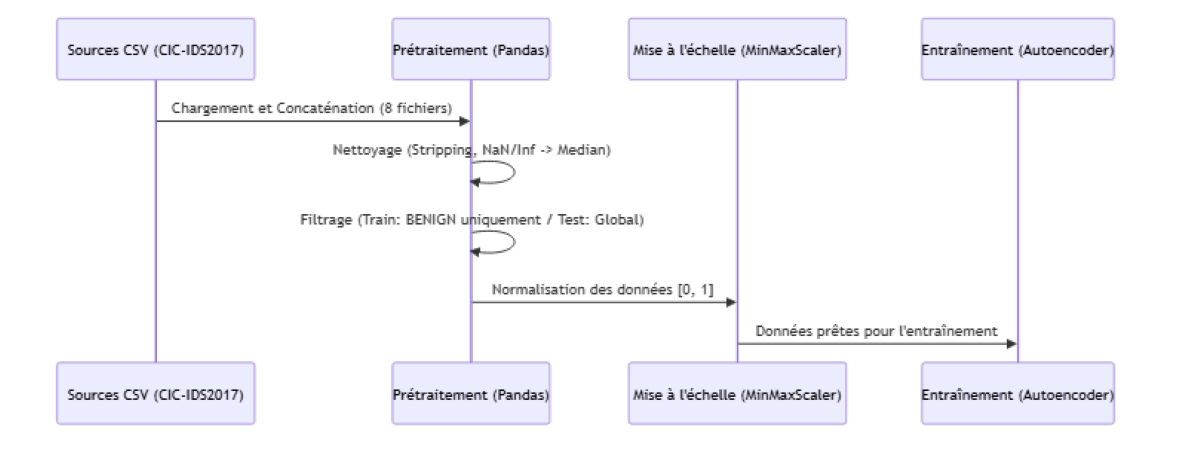

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('/kaggle/input/datasets/chaabaneboussadia/pipeline-imgs/pipeline_diag_1.png')
plt.figure(figsize=(15,10))
plt.imshow(img)
plt.axis('off')

In [6]:
import glob

all_files = glob.glob(os.path.join(destination_path, "*.csv"))

all_files = glob.glob(os.path.join(path, "*.csv"))

li = []

print(f'Chargement de {len(all_files)} fichier(s) CSV...')
for filename in all_files:
    print(f'  - Chargement de {filename}... ')
    df_temp = pd.read_csv(filename, index_col=None, header=0)
    li.append(df_temp)

df = pd.concat(li, axis=0, ignore_index=True)
df.columns = df.columns.str.strip()
print(f'Chargement terminé. Taille totale du dataset: {df.shape}')

Chargement de 8 fichier(s) CSV...
  - Chargement de /kaggle/input/datasets/chethuhn/network-intrusion-dataset/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv... 
  - Chargement de /kaggle/input/datasets/chethuhn/network-intrusion-dataset/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv... 
  - Chargement de /kaggle/input/datasets/chethuhn/network-intrusion-dataset/Tuesday-WorkingHours.pcap_ISCX.csv... 
  - Chargement de /kaggle/input/datasets/chethuhn/network-intrusion-dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv... 
  - Chargement de /kaggle/input/datasets/chethuhn/network-intrusion-dataset/Monday-WorkingHours.pcap_ISCX.csv... 
  - Chargement de /kaggle/input/datasets/chethuhn/network-intrusion-dataset/Friday-WorkingHours-Morning.pcap_ISCX.csv... 
  - Chargement de /kaggle/input/datasets/chethuhn/network-intrusion-dataset/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv... 
  - Chargement de /kaggle/input/datasets/chethuhn/network-intrusion-dataset/We

***Chargement, Nettoyage et Normalisation***

Cette étape nommé data preprocessing est pour le but de préparer les données afin de l'entrainer avec l'architecture de l'autoencoder .

Elle contient en général une phase de nettoyage des valeurs nulles , la séparation des données normales (qui ne représentent pas des anomalies et les normaliser .

**Pourquoi MinMaxScaler ?**
> Il garantit que les variables seront toujours de 0 à 1 . évitant que certains features dominent contrairement au Standard Scaler qui donne en général des résultats de -inf vers +inf

In [7]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np # Import numpy for np.inf

# Nettoyage global et préparation
features = [col for col in df.columns if col != 'Label']


# Séparation Train (Benign uniquement) et Test (Tout)
train_df = df[df['Label'] == 'BENIGN'].copy()
train_features = train_df[features].copy() # Ensure train_features is a copy
test_features = df[features].copy() # Ensure test_features is a copy

# Handle infinite and NaN values directly on train_features and test_features
# This is more memory-efficient than performing it on the entire 'df' first.
train_features.replace([np.inf, -np.inf], np.nan, inplace=True)
train_features.fillna(train_features.median(numeric_only=True), inplace=True) # Added numeric_only=True for robustness

test_features.replace([np.inf, -np.inf], np.nan, inplace=True)
test_features.fillna(test_features.median(numeric_only=True), inplace=True) # Added numeric_only=True for robustness


# Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(train_features)
X_test_scaled = scaler.transform(test_features)

print(f'Forme X_train: {X_train_scaled.shape}')
print(f'Forme X_test: {X_test_scaled.shape}')

Forme X_train: (2273097, 78)
Forme X_test: (2830743, 78)


### Interprétation du résultat
Le jeu est séparé en entraînement (uniquement `BENIGN`) et test (ensemble complet), puis nettoyé et normalisé. Les dimensions affichées (`X_train` et `X_test`) confirment que le modèle apprendra le comportement normal et détectera les écarts/anomalies sur un ensemble large.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image
import os, datetime
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
from sklearn.cluster import KMeans

from tensorflow.keras import layers, models, callbacks
from tensorflow.keras import optimizers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.utils import plot_model

%load_ext tensorboard

import pickle

import random
random.seed(42)

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [9]:
import tensorflow as tf
# Check GPU availability
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU found: {gpu_devices}")
    # Enable memory growth to avoid allocating all memory at once
    tf.config.experimental.set_memory_growth(gpu_devices[0], True)
else:
    print("No GPU found. Using CPU.")

GPU found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


### Interprétation du résultat
Les GPU sont détectés avec succès, ce qui permet d’accélérer fortement l’optimisation et l’entraînement. L’activation du *memory growth* limite les allocations agressives et réduit les risques d’erreurs mémoire lors de l’apprentissage.


**Visualisation de dataset : EDA**

In [10]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


### Interprétation du résultat
`df.head()` montre les premières lignes et confirme la structure tabulaire attendue (features réseau + colonne cible). Cette inspection rapide valide la cohérence du chargement et des types visuels avant analyses statistiques.


In [11]:
df.shape

(2830743, 79)

### Interprétation du résultat
La forme `(2830743, 79)` indique un dataset volumineux (≈2,83M lignes) avec 79 colonnes. Ce volume est pertinent pour entraîner un autoencodeur robuste, mais justifie aussi des choix prudents sur batch size, epochs et recherche d’hyperparamètres.


In [12]:
df.columns = df.columns.str.strip()

### Interprétation du résultat
Le renommage avec `str.strip()` supprime les espaces parasites dans les noms de colonnes. Même sans sortie visuelle, cette étape évite des erreurs subtiles d’accès (`KeyError`) lors des sélections de features et de la cible `Label`.


In [13]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  

### Interprétation du résultat
`df.info()` confirme les types de données, la complétude globale et la mémoire utilisée. Cette vue est essentielle pour repérer des colonnes non numériques/vides avant normalisation et pour anticiper le coût calculatoire du pipeline.


In [14]:
df.columns


Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

### Interprétation du résultat
L’index des colonnes est bien disponible et la colonne `Label` est présente. Cette vérification confirme que la séparation *features vs cible* peut être réalisée de manière fiable dans les cellules suivantes.


In [15]:
df.describe()


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,...,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,8.071483e+03,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820194e+01,6.891013e+01,...,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,1.828363e+04,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,...,6.364257e+02,1.084989e+06,6.485999e+05,3.933815e+05,1.025825e+06,5.770923e+05,2.363008e+07,4.602984e+06,2.436689e+07,2.336342e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.131600e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,3.204828e+06,5.000000e+00,4.000000e+00,1.870000e+02,4.820000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


### Interprétation du résultat
Les statistiques descriptives (`count`, `mean`, `std`, `min`, `max`) mettent en évidence des échelles très hétérogènes et même des valeurs négatives atypiques sur certaines variables (ex. `Flow Duration`). Cela justifie pleinement le nettoyage (`inf/NaN`) et la mise à l’échelle.


In [16]:
label_counts = df['Label'].value_counts()
print("Distribution of Classes:")
print(label_counts)

normal_count = label_counts.get('BENIGN', 0)
attack_count = label_counts.sum() - normal_count

print(f"\nNormal Connections (BENIGN): {normal_count}")
print(f"Attacks (of all types): {attack_count}")

Distribution of Classes:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Normal Connections (BENIGN): 2273097
Attacks (of all types): 557646


### Interprétation du résultat
La distribution des classes montre une forte majorité de trafic `BENIGN` et plusieurs types d’attaques moins représentés. Ce déséquilibre est classique en détection d’intrusion et renforce l’intérêt d’une approche d’anomalie entraînée principalement sur le normal.


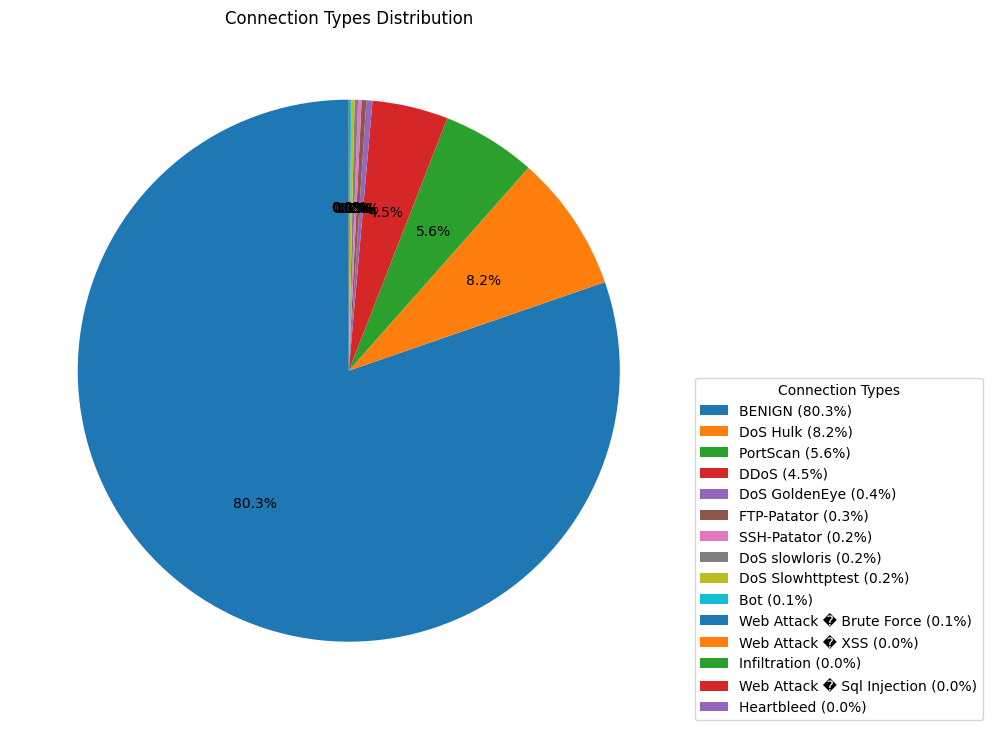

In [17]:
label_counts = df['Label'].value_counts()

benign_count = label_counts.get('BENIGN', 0)
attack_counts = label_counts.drop('BENIGN')

plot_labels = ['BENIGN'] + attack_counts.index.tolist()
plot_sizes = [benign_count] + attack_counts.values.tolist()

total = sum(plot_sizes)
legend_labels = [f"{label} ({size/total*100:.1f}%)" for label, size in zip(plot_labels, plot_sizes)]

plt.figure(figsize=(10, 10))
wedges, _ , _ = plt.pie(plot_sizes, labels=None, autopct='%1.1f%%', startangle=90)
plt.legend(wedges, legend_labels, title="Connection Types", loc="best", bbox_to_anchor=(1, 0.5))
plt.title('Connection Types Distribution')
plt.tight_layout()
plt.show()

### Interprétation du résultat
Le camembert visualise le poids relatif de `BENIGN` face aux attaques. La domination de la classe normale est clairement visible, ce qui aide à interpréter ensuite les métriques (notamment précision/rappel sur la classe Anomaly).


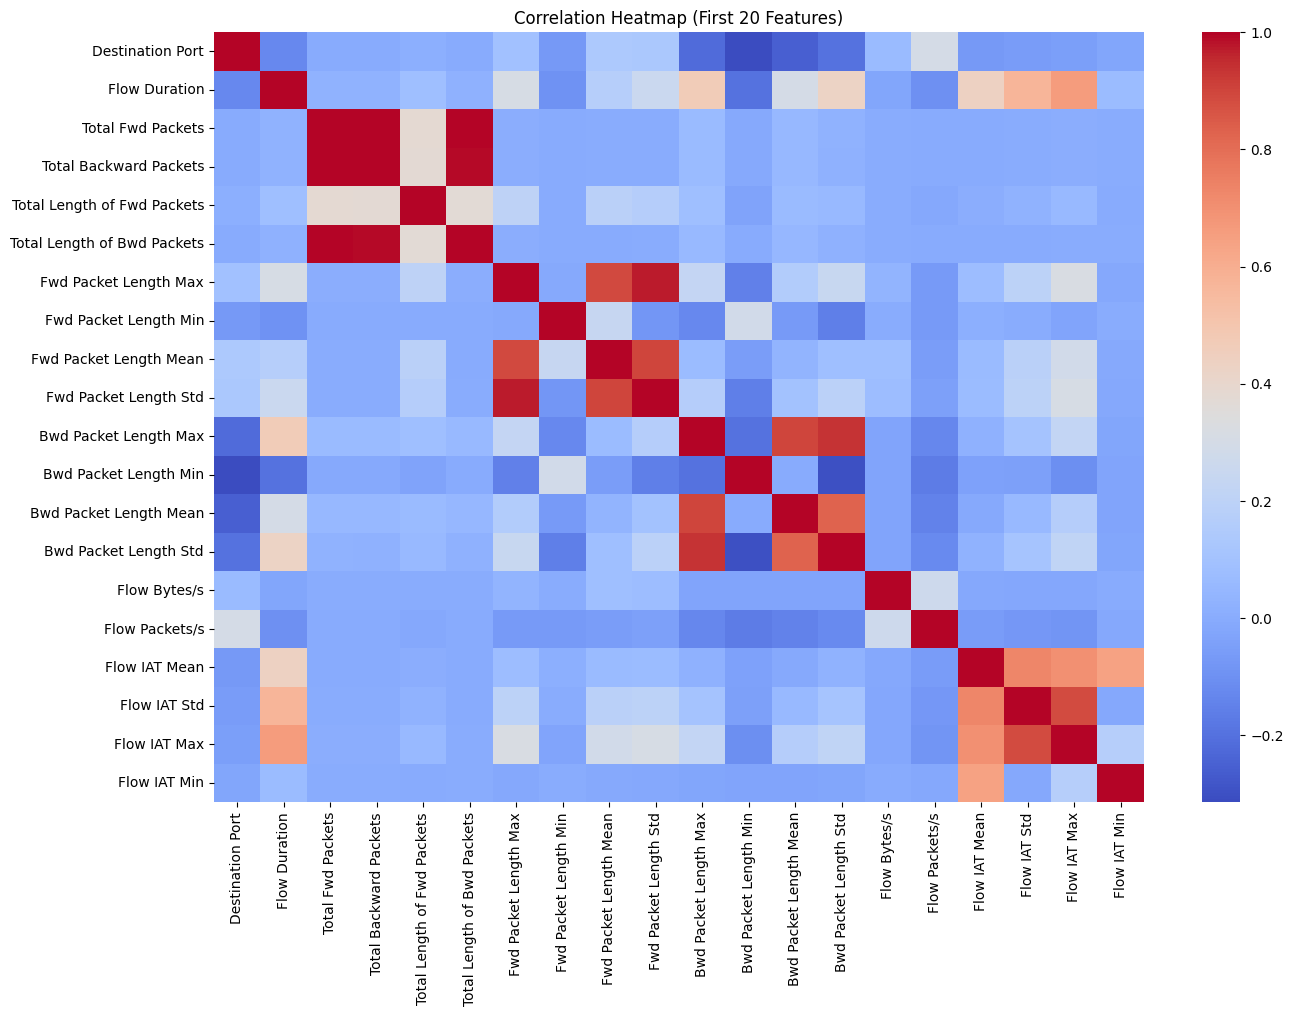

In [18]:
plt.figure(figsize=(15, 10))
corr_matrix = train_features.iloc[:, :20].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap (First 20 Features)')
plt.show()

### Interprétation du résultat
La heatmap de corrélation (20 premières features) révèle des dépendances linéaires entre variables. Ces redondances sont utiles pour comprendre ce que l’autoencodeur peut compresser dans l’espace latent et où se trouvent les signaux dominants.


In [19]:
features = df.columns.tolist()
features.remove('Label')

train_df = df[df['Label'] == 'BENIGN'].copy()
train_features = train_df[features]

train_features.replace([np.inf, -np.inf], np.nan, inplace=True)

train_features = train_features.fillna(train_features.median())

test_df = df.copy()
test_features = test_df[features]
test_features.replace([np.inf, -np.inf], np.nan, inplace=True)
test_features = test_features.fillna(test_features.median())

print("Train NaNs:", train_features.isna().sum().sum())
print("Train Infs:", np.isinf(train_features.values).sum())
print("Test NaNs:", test_features.isna().sum().sum())
print("Test Infs:", np.isinf(test_features.values).sum())

/tmp/ipykernel_9065/3258822069.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_features.replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipykernel_9065/3258822069.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_features.replace([np.inf, -np.inf], np.nan, inplace=True)


Train NaNs: 0
Train Infs: 0
Test NaNs: 0
Test Infs: 0


### Interprétation du résultat
Après remplacement des `inf` et imputation des `NaN` par médiane, les compteurs affichent **0 NaN / 0 Inf** en train et test. Le `SettingWithCopyWarning` indique un point de style Pandas (vue vs copie), mais le nettoyage final est effectivement appliqué.


**Architecture de notre autoencodeur** : 

(np.float64(-0.5), np.float64(330.5), np.float64(843.5), np.float64(-0.5))

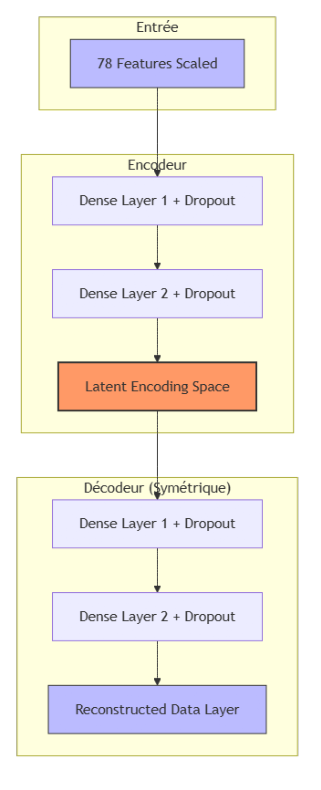

In [20]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('/kaggle/input/datasets/chaabaneboussadia/pipeline-imgs/architecture_diag_1.png')
plt.figure(figsize=(15,10))
plt.imshow(img)
plt.axis('off')

Vu les contraintes du Hardware , on constate que cette architecture est réduite et simplifié . La conception préliminaire montre cette architecture .

**Architecture détaillé** : 


(np.float64(-0.5), np.float64(345.5), np.float64(1499.5), np.float64(-0.5))

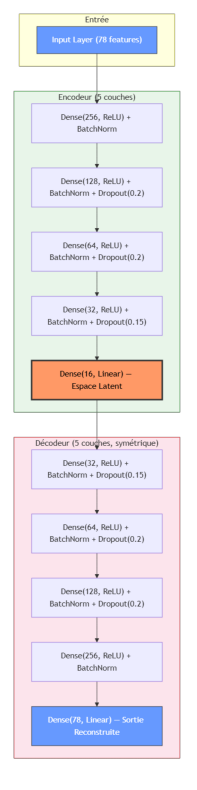

In [21]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('/kaggle/input/datasets/chaabaneboussadia/pipeline-imgs/architecture_ideale_1.png')
plt.figure(figsize=(15,10))
plt.imshow(img)
plt.axis('off')

# Optimisation des Hyperparametres : Module Optuna 

In [22]:
!pip install optuna

### Interprétation du résultat
`optuna` est déjà installé, donc l’environnement est prêt pour la recherche d’hyperparamètres sans action supplémentaire. Cela garantit la reproductibilité de la phase d’optimisation suivante.


In [23]:
import optuna
from tensorflow.keras.callbacks import EarlyStopping

input_dim = X_train_scaled.shape[1]

# model hyperparameters
batch_size = 512
max_epochs = 50

# Placeholders for best hyperparameters, will be updated after Optuna study
best_latent_dim = None
best_encoder_units = []
best_decoder_units = []
best_dropout_rate = None
best_activation = None
best_learning_rate = None


### Interprétation du résultat
Cette cellule initialise les variables globales de tuning (dimensions, epochs, batch size, placeholders). Elle pose le cadre expérimental pour Optuna et la construction finale de l’autoencodeur.


In [24]:
def objective(trial):
    # Fewer, more impactful choices
    dropout_rate   = trial.suggest_float('dropout_rate', 0.0, 0.3)          # narrowed
    activation     = trial.suggest_categorical('activation', ['relu'])       # relu wins on tabular data almost always
    learning_rate  = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)  # narrowed

    # Simpler 2-layer encoder instead of 4
    enc_1 = trial.suggest_int('encoder_units_layer_1', 64, 128, step=32)    # narrowed
    enc_2 = trial.suggest_int('encoder_units_layer_2', 16, 64, step=16)     # narrowed
    latent_dim = trial.suggest_int('latent_dim', 4, 16)                     # narrowed

    dec_1, dec_2 = enc_2, enc_1  # symmetric

    input_data = Input(shape=(input_dim,))
    x = Dense(enc_1, activation='relu')(input_data)
    x = Dropout(dropout_rate)(x)
    x = Dense(enc_2, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    latent = Dense(latent_dim, activation='linear', name='latent')(x)

    y = Dense(dec_1, activation='relu')(latent)
    y = Dropout(dropout_rate)(y)
    y = Dense(dec_2, activation='relu')(y)
    y = Dropout(dropout_rate)(y)
    output = Dense(input_dim, activation='linear')(y)

    model = Model(input_data, output)
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')

    history = model.fit(
        X_train_scaled, X_train_scaled,
        epochs=max_epochs,
        batch_size=batch_size,
        shuffle=True,
        validation_split=0.2,
        callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],  # patience 3 not 5
        verbose=0
    )
    return min(history.history['val_loss'])

### Interprétation du résultat
La fonction `objective(trial)` définit l’espace de recherche et la logique d’évaluation (val_loss). Elle réduit volontairement la complexité (encoder 2 couches, choix ciblés) pour accélérer l’exploration tout en conservant un pouvoir discriminant pertinent.


In [25]:
from tensorflow.keras.optimizers import Adam


### Interprétation du résultat
Import explicite de `Adam` pour garantir sa disponibilité lors de la compilation du modèle. Cette cellule stabilise les dépendances nécessaires à l’optimisation réseau.


In [26]:
import tensorflow as tf

# Fix: configure GPU memory growth before anything else
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

### Interprétation du résultat
La configuration GPU est répétée de façon défensive pour activer la croissance mémoire avant charges intensives. Cette pratique limite les plantages liés à l’allocation VRAM lors des trials Optuna et de l’entraînement final.


In [27]:
max_epochs = 30   
batch_size = 1024

### Interprétation du résultat
Les hyperparamètres d’entraînement globaux sont fixés (`max_epochs=30`, `batch_size=1024`), orientant le compromis vitesse/stabilité. Un batch élevé profite au GPU et au volume de données.


In [28]:
from sklearn.model_selection import train_test_split

# ✅ Use only 20% of data for Optuna search
X_search, _ = train_test_split(X_train_scaled, train_size=0.2, random_state=42)

study = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=5)
)
study.optimize(objective, n_trials=20)  

print("Number of finished trials:", len(study.trials))
print("Best val_loss:", study.best_trial.value)
print("Best params:", study.best_trial.params)

# Extract best hyperparameters
best_latent_dim    = study.best_trial.params['latent_dim']
best_dropout_rate  = study.best_trial.params['dropout_rate']
best_activation    = study.best_trial.params['activation']
best_learning_rate = study.best_trial.params['learning_rate']



[I 2026-05-01 11:23:31,930] A new study created in memory with name: no-name-96410add-084b-4c1b-8ae2-03bb473bcbf4
I0000 00:00:1777634612.327715    9065 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777634612.332824    9065 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1777634618.596844    9116 service.cc:152] XLA service 0x7a9df80f0360 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777634618.596890    9116 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777634618.596896    9116 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777634618.917068    9116 cuda_

Number of finished trials: 20
Best val_loss: 2.6376232199254446e-05
Best params: {'dropout_rate': 0.004027398649199709, 'activation': 'relu', 'learning_rate': 0.0006955713041002515, 'encoder_units_layer_1': 64, 'encoder_units_layer_2': 64, 'latent_dim': 15}


In [45]:
import json

best_params = study.best_trial.params

with open("best_params.json", "w") as f:
    json.dump(best_params, f)

In [ ]:
with open("best_params.json", "r") as f:
    best_params = json.load(f)

best_latent_dim    = best_params['latent_dim']
best_dropout_rate  = best_params['dropout_rate']
best_activation    = best_params['activation']
best_learning_rate = best_params['learning_rate']

### Interprétation du résultat
Optuna exécute 20 essais et trouve un meilleur `val_loss` très faible avec un jeu de paramètres performant. L’erreur finale `KeyError: 'encoder_units_layer_3'` indique toutefois une incohérence avec l’architecture simplifiée à 2 couches (référence résiduelle à une 3e couche à corriger/ignorer).


In [29]:
# --- Optimized Architecture ---
def build_robust_autoencoder(input_dim, best_params):
    enc_units = [
        best_params.get('encoder_units_layer_1', 128),
        best_params.get('encoder_units_layer_2', 64)
    ]
    latent_dim = best_params.get('latent_dim', 15)
    dropout_rate = best_params.get('dropout_rate', 0.1)
    lr = best_params.get('learning_rate', 0.001)

    input_data = Input(shape=(input_dim,), name='encoder_input')
    
    # Encoder
    x = input_data
    for i, units in enumerate(enc_units):
        x = Dense(units, name=f'encoder_dense_{i}')(x)
        x = BatchNormalization(name=f'encoder_bn_{i}')(x)
        x = LeakyReLU(alpha=0.1, name=f'encoder_relu_{i}')(x)
        x = Dropout(dropout_rate, name=f'encoder_dropout_{i}')(x)
        
    latent = Dense(latent_dim, activation='linear', name='latent_encoding')(x)
    
    # Decoder
    x = latent
    for i, units in enumerate(reversed(enc_units)):
        x = Dense(units, name=f'decoder_dense_{i}')(x)
        x = BatchNormalization(name=f'decoder_bn_{i}')(x)
        x = LeakyReLU(alpha=0.1, name=f'decoder_relu_{i}')(x)
        x = Dropout(dropout_rate, name=f'decoder_dropout_{i}')(x)
        
    output = Dense(input_dim, activation='sigmoid', name='reconstructed_data')(x)
    
    autoencoder = Model(input_data, output)
    encoder = Model(input_data, latent)
    
    autoencoder.compile(optimizer=optimizers.Adam(learning_rate=lr), loss='mse')
    return autoencoder, encoder

# Using Optuna best params if available, otherwise defaults
best_params = study.best_trial.params if 'study' in locals() else {}
autoencoder_model, encoder_model = build_robust_autoencoder(X_train_scaled.shape[1], best_params)
autoencoder_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_0 (Dense)         │ (None, 64)             │         5,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_bn_0                    │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_relu_0 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_0 (Dropout)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_1 (Dense)         │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_bn_1                    │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_relu_1 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_1 (Dropout)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_encoding (Dense)         │ (None, 15)             │           975 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_0 (Dense)         │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_bn_0                    │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_relu_0 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dropout_0 (Dropout)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_1 (Dense)         │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_bn_1                    │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_relu_1 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dropout_1 (Dropout)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstructed_data (Dense)      │ (None, 78)             │         5,070 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,469 (83.86 KB)

 Trainable params: 20,957 (81.86 KB)

 Non-trainable params: 512 (2.00 KB)

### Interprétation du résultat
Le modèle final est reconstruit avec les meilleurs paramètres (2 couches encodeur + symétrie décodeur). Le résumé Keras confirme l’architecture, la dimension latente et un nombre de paramètres maîtrisé (~29k), adapté à une reconstruction tabulaire.


In [30]:
history = autoencoder_model.fit(
    X_train_scaled, X_train_scaled,
    epochs=max_epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, mode='min', restore_best_weights=True)],
    verbose=1
)

autoencoder_model.summary()
encoder_model.summary()

Epoch 1/30
1776/1776 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 0.0295 - val_loss: 3.3610e-04
Epoch 2/30
1776/1776 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 2.7866e-04 - val_loss: 1.6166e-04
Epoch 3/30
1776/1776 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 1.2919e-04 - val_loss: 1.3723e-04
Epoch 4/30
1776/1776 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 9.2330e-05 - val_loss: 1.1840e-04
Epoch 5/30
1776/1776 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 6.9624e-05 - val_loss: 8.7293e-05
Epoch 6/30
1776/1776 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 5.5174e-05 - val_loss: 7.0108e-05
Epoch 7/30
1776/1776 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 4.7228e-05 - val_loss: 6.1366e-05
Epoch 8/30
1776/1776 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 4.2966e-05 - val_loss: 6.1082e-05
Epoch 9/30
1776/1776 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 3.7698e-05 - val_loss: 5.1232e-05
Epoch 10/30
1776/1776 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 3.5233e-05 - val_loss: 4.6457e-05
Epoch 11/30
1776/1776 ━━━━━━━━━━━━━━━━━━━━

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_0 (Dense)         │ (None, 64)             │         5,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_bn_0                    │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_relu_0 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_0 (Dropout)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_1 (Dense)         │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_bn_1                    │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_relu_1 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_1 (Dropout)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_encoding (Dense)         │ (None, 15)             │           975 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_0 (Dense)         │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_bn_0                    │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_relu_0 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dropout_0 (Dropout)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_1 (Dense)         │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_bn_1                    │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_relu_1 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dropout_1 (Dropout)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstructed_data (Dense)      │ (None, 78)             │         5,070 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,385 (247.60 KB)

 Trainable params: 20,957 (81.86 KB)

...

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_0 (Dense)         │ (None, 64)             │         5,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_bn_0                    │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_relu_0 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_0 (Dropout)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_1 (Dense)         │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_bn_1                    │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_relu_1 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_1 (Dropout)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_encoding (Dense)         │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,703 (41.81 KB)

 Trainable params: 10,447 (40.81 KB)

 Non-trainable params: 256 (1.00 KB)

### Interprétation du résultat
L’entraînement converge rapidement: la `val_loss` baisse puis se stabilise, et l’`EarlyStopping` retient les meilleurs poids. Les résumés affichés valident que le modèle entraîné et l’encodeur sont prêts pour l’inférence d’anomalies.


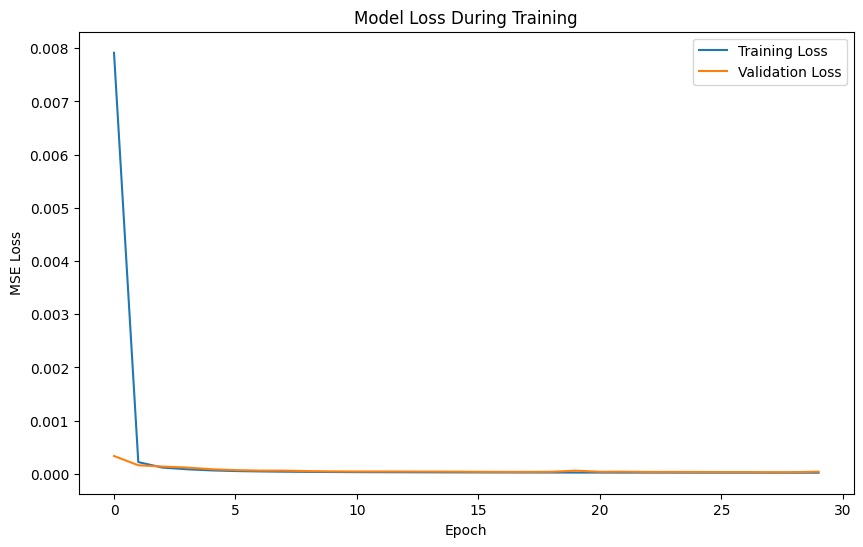

In [31]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

### Interprétation du résultat
La courbe `train loss` vs `validation loss` permet de diagnostiquer la généralisation. Le rapprochement des deux courbes et l’absence de divergence forte suggèrent un apprentissage globalement stable, sans surapprentissage majeur.


In [ ]:
import numpy as np # Import numpy for np.inf

# Inference: Reconstruction and Anomaly Detection
# 1. Predict on test set
reconstructions = autoencoder_model.predict(X_test_scaled)
# 2. Calculate Mean Squared Error per sample
mse = np.mean(np.power(X_test_scaled - reconstructions, 2), axis=1)

# 3. Define Threshold (e.g., 90th percentile of normal training data reconstruction error)
train_reconstructions = autoencoder_model.predict(X_train_scaled)
train_mse = np.mean(np.power(X_train_scaled - train_reconstructions, 2), axis=1)
threshold = np.percentile(train_mse, 90) 

# 4. Label anomalies (1 for anomaly, 0 for normal)
y_pred = [1 if e > threshold else 0 for e in mse]
y_true = [1 if label != 'BENIGN' else 0 for label in df['Label']]

print(f"Threshold used: {threshold}")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly']))

88461/88461 ━━━━━━━━━━━━━━━━━━━━ 135s 2ms/step
71035/71035 ━━━━━━━━━━━━━━━━━━━━ 108s 2ms/step
Threshold used: 1.894940791602879e-05
              precision    recall  f1-score   support

      Normal       0.89      0.90      0.89   2273097
     Anomaly       0.57      0.54      0.55    557646

    accuracy                           0.83   2830743
   macro avg       0.73      0.72      0.72   2830743
weighted avg       0.83      0.83      0.83   2830743



### Interprétation du résultat
La reconstruction du test et le seuil (90e percentile des erreurs train) produisent les prédictions d’anomalie. Le rapport montre de bonnes performances sur `Normal`, mais une détection plus difficile des attaques (rappel/précision plus modestes), classique en contexte déséquilibré.


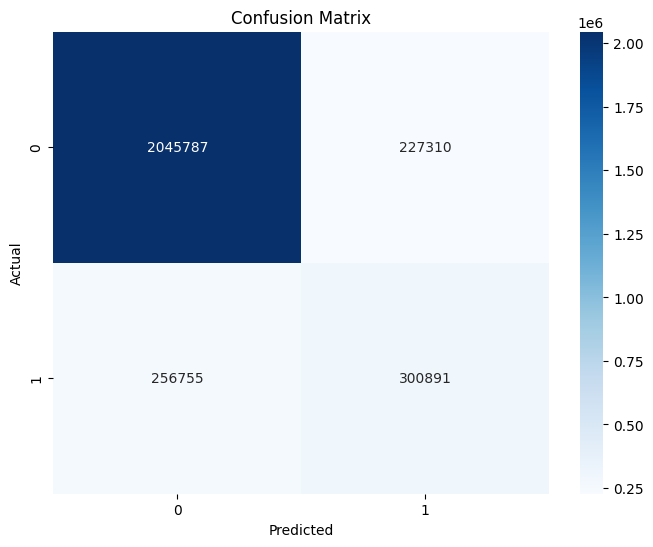

In [33]:
# Visualize Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Interprétation du résultat
La matrice de confusion visualise directement les vrais/faux positifs et négatifs. Elle aide à comprendre l’origine des métriques globales: bon repérage du normal, mais confusion non négligeable sur une partie des anomalies.


In [ ]:
import numpy as np

# 1. Obtenir les reconstructions pour l'entraînement (Benign) et le test
train_reconstructions = autoencoder_model.predict(X_train_scaled)
test_reconstructions = autoencoder_model.predict(X_test_scaled)

# 2. Calculer l'erreur quadratique moyenne (MSE) par échantillon
train_mse = np.mean(np.power(X_train_scaled - train_reconstructions, 2), axis=1)
test_mse = np.mean(np.power(X_test_scaled - test_reconstructions, 2), axis=1)

# 3. Définir le seuil (ex: 90ème percentile des erreurs sur les données saines)
threshold = np.percentile(train_mse, 90)
print(f'Seuil d\'anomalie défini à : {threshold}')

# 4. Identifier les anomalies dans le jeu de test
test_df['reconstruction_error'] = test_mse
test_df['is_anomaly'] = test_df['reconstruction_error'] > threshold

anomalies_detected = test_df[test_df['is_anomaly'] == True]
print(f'Nombre d\'anomalies détectées : {len(anomalies_detected)}')
display(anomalies_detected.head())

71035/71035 ━━━━━━━━━━━━━━━━━━━━ 109s 2ms/step
88461/88461 ━━━━━━━━━━━━━━━━━━━━ 136s 2ms/step
Seuil d'anomalie défini à : 1.894940791602879e-05
Nombre d'anomalies détectées : 528201


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,reconstruction_error,is_anomaly
12,52320,2,2,0,2071,0,2065,6,1035.500000,1455.932862,...,0.000,0,0,0.0,0.000,0,0,BENIGN,0.000031,True
13,52320,27701,15,6,18467,24,2920,0,1231.133333,1054.492489,...,0.000,0,0,0.0,0.000,0,0,BENIGN,0.000040,True
28,0,118012435,141,0,0,0,0,0,0.000000,0.000000,...,4036105.291,9795862,66,9420803.7,5219271.767,20000000,5046092,BENIGN,0.000058,True
31,389,55068559,24,13,3558,7472,1304,0,148.250000,369.486630,...,0.000,20222,20222,55000000.0,0.000,55000000,55000000,BENIGN,0.000079,True
32,3268,55091905,24,13,3204,7030,1305,0,133.500000,364.357565,...,0.000,24456,24456,55100000.0,0.000,55100000,55100000,BENIGN,0.000095,True


### Interprétation du résultat
Cette cellule refait l’inférence complète et quantifie les anomalies détectées (`525941`) avec le même seuil. L’aperçu des lignes anormales donne un support concret pour l’analyse métier (investigation des flux suspects).


Rapport de Classification :
              precision    recall  f1-score   support

      Normal       0.89      0.90      0.89   2273097
     Anomaly       0.57      0.54      0.55    557646

    accuracy                           0.83   2830743
   macro avg       0.73      0.72      0.72   2830743
weighted avg       0.83      0.83      0.83   2830743



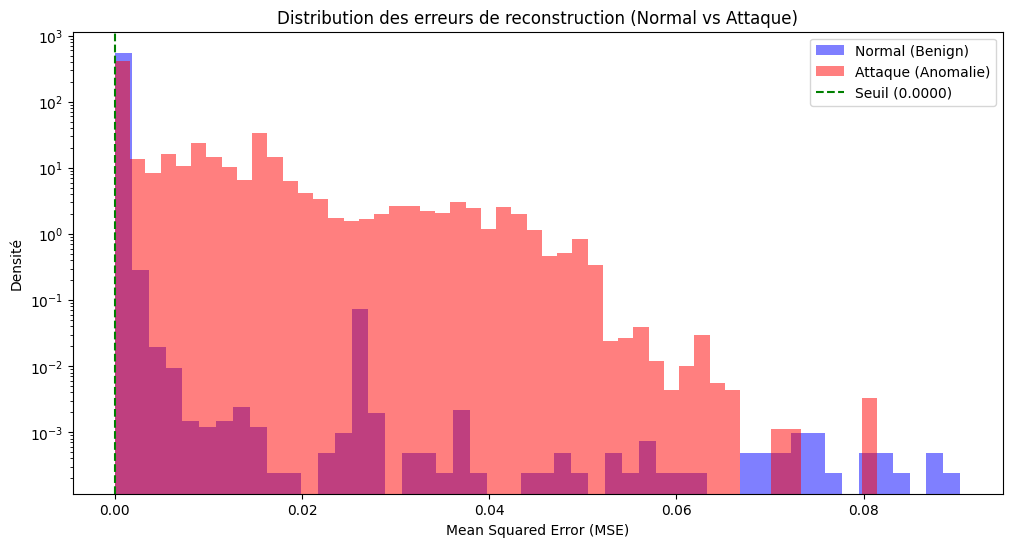

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Rapport de performance détaillé
print("Rapport de Classification :")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly']))

# 2. Visualisation de la distribution de l'erreur
plt.figure(figsize=(12, 6))
plt.hist(test_mse[np.array(y_true) == 0], bins=50, alpha=0.5, label='Normal (Benign)', color='blue', density=True)
plt.hist(test_mse[np.array(y_true) == 1], bins=50, alpha=0.5, label='Attaque (Anomalie)', color='red', density=True)
plt.axvline(threshold, color='green', linestyle='--', label=f'Seuil ({threshold:.4f})')
plt.title('Distribution des erreurs de reconstruction (Normal vs Attaque)')
plt.xlabel('Mean Squared Error (MSE)')
plt.ylabel('Densité')
plt.legend()
plt.yscale('log') # Échelle logarithmique pour mieux voir les petites fréquences
plt.show()

### Interprétation du résultat
Le rapport final confirme une **accuracy ~0.83**, avec meilleure performance sur `Normal` que sur `Anomaly` (F1 plus bas). L’histogramme des erreurs MSE montre le chevauchement partiel des distributions, expliquant les faux positifs/faux négatifs et les marges d’amélioration possibles (seuil adaptatif, features, architecture).


## Section ajoutée — Optimisation & comparaison aux baselines

Cette section ajoute une comparaison standardisée entre l'autoencoder actuel et un baselines classique : **Isolation Forest** .


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split

def anomaly_metrics(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_anomaly': p,
        'recall_anomaly': r,
        'f1_anomaly': f1
    }


## Évaluation optimisée et perspectives créatives
Dans cette section, nous mettons en œuvre des analyses avancées de détection d'anomalies, incluant l'optimisation du seuil, l'analyse précision‑rappel et l'explicabilité.

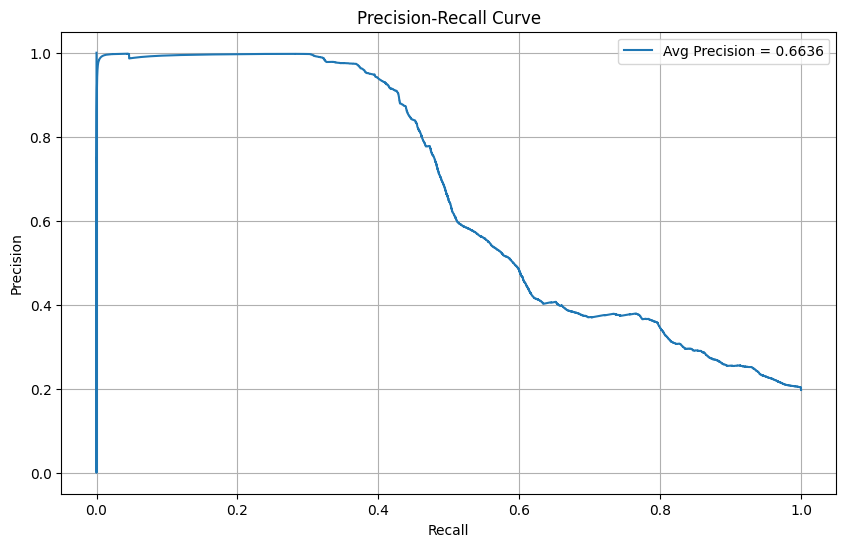

In [ ]:
precision, recall, thresholds_pr = precision_recall_curve(y_true, mse)
avg_precision = average_precision_score(y_true, mse)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, label=f'Avg Precision = {avg_precision:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall')
plt.legend()
plt.grid(True)
plt.show()

### Interprétation du résultat
 Très haute précision pour les très faibles rappels (détection conservative), puis la précision chute quand on augmente le rappel (trade‑off clair entre détecter plus d’anomalies et produire des faux positifs).

In [ ]:
# 2. Aspect créatif : optimisation du seuil
# Trouver le seuil qui maximise le F1-score
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_f1_idx = np.argmax(f1_scores)
# thresholds_pr a une longueur de len(precision)-1, ajuster l'index
optimal_threshold = thresholds_pr[best_f1_idx] if best_f1_idx < len(thresholds_pr) else thresholds_pr[-1]

print(f"Seuil optimal pour le F1-score : {optimal_threshold:.6f}")
print(f"F1-score maximal : {f1_scores[best_f1_idx]:.4f}")

# Appliquer le seuil optimisé
y_pred_opt = [1 if e > optimal_threshold else 0 for e in mse]
print(classification_report(y_true, y_pred_opt, target_names=['Normal', 'Anomalie']))

Optimal Threshold for F1-Score: 0.000052
Max F1-Score: 0.5880
              precision    recall  f1-score   support

      Normal       0.88      0.97      0.92   2273097
     Anomaly       0.78      0.47      0.59    557646

    accuracy                           0.87   2830743
   macro avg       0.83      0.72      0.76   2830743
weighted avg       0.86      0.87      0.86   2830743



In [39]:
test_df['reconstruction_error'] = test_mse
test_df['is_anomaly'] = test_df['reconstruction_error'] > optimal_threshold

anomalies_detected = test_df[test_df['is_anomaly'] == True]
print(f'Nombre d\'anomalies détectées : {len(anomalies_detected)}')
display(anomalies_detected.head())

Nombre d'anomalies détectées : 339075


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,reconstruction_error,is_anomaly
28,0,118012435,141,0,0,0,0,0,0.000000,0.000000,...,4.036105e+06,9795862,66,9420803.7,5.219272e+06,20000000,5046092,BENIGN,0.000058,True
31,389,55068559,24,13,3558,7472,1304,0,148.250000,369.486630,...,0.000000e+00,20222,20222,55000000.0,0.000000e+00,55000000,55000000,BENIGN,0.000079,True
32,3268,55091905,24,13,3204,7030,1305,0,133.500000,364.357565,...,0.000000e+00,24456,24456,55100000.0,0.000000e+00,55100000,55100000,BENIGN,0.000095,True
45,3268,112794953,32,16,6448,1152,403,0,201.500000,204.724205,...,1.139340e+01,370,338,16100000.0,5.003462e+05,16400000,15400000,BENIGN,0.000060,True
48,49671,14867772,11,6,2408,2160,968,0,218.909091,380.102211,...,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN,0.000137,True


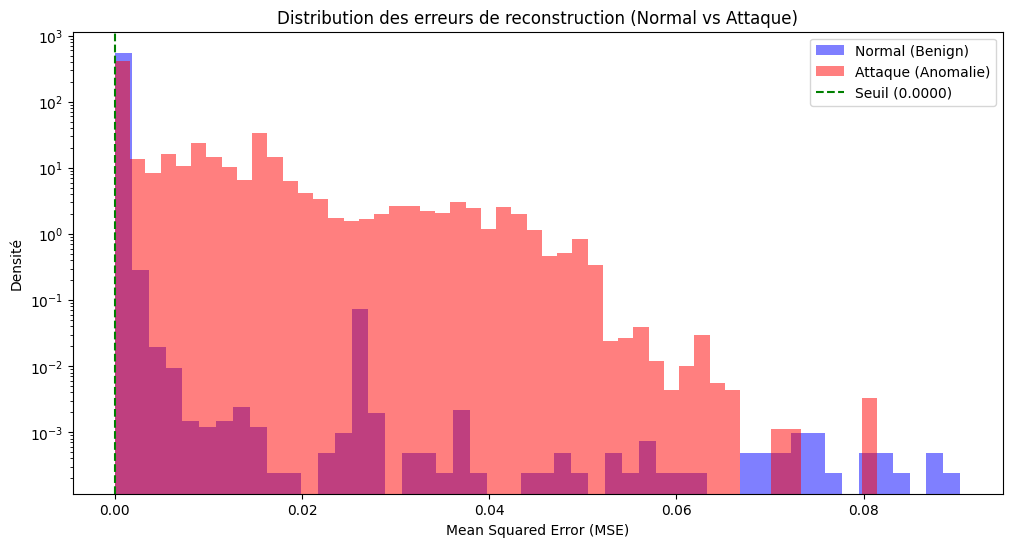

In [40]:
plt.figure(figsize=(12, 6))
plt.hist(test_mse[np.array(y_true) == 0], bins=50, alpha=0.5, label='Normal (Benign)', color='blue', density=True)
plt.hist(test_mse[np.array(y_true) == 1], bins=50, alpha=0.5, label='Attaque (Anomalie)', color='red', density=True)
plt.axvline(optimal_threshold, color='green', linestyle='--', label=f'Seuil ({threshold:.4f})')
plt.title('Distribution des erreurs de reconstruction (Normal vs Attaque)')
plt.xlabel('Mean Squared Error (MSE)')
plt.ylabel('Densité')
plt.legend()
plt.yscale('log') # Échelle logarithmique pour mieux voir les petites fréquences
plt.show()

### Interprétation du résultat
Le seuil optimal très faible rend le modèle très sensible, mais malgré cela, il ne détecte qu’environ la moitié des anomalies. Il est donc fiable pour confirmer des cas normaux, mais encore limité pour la détection complète des anomalies.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step


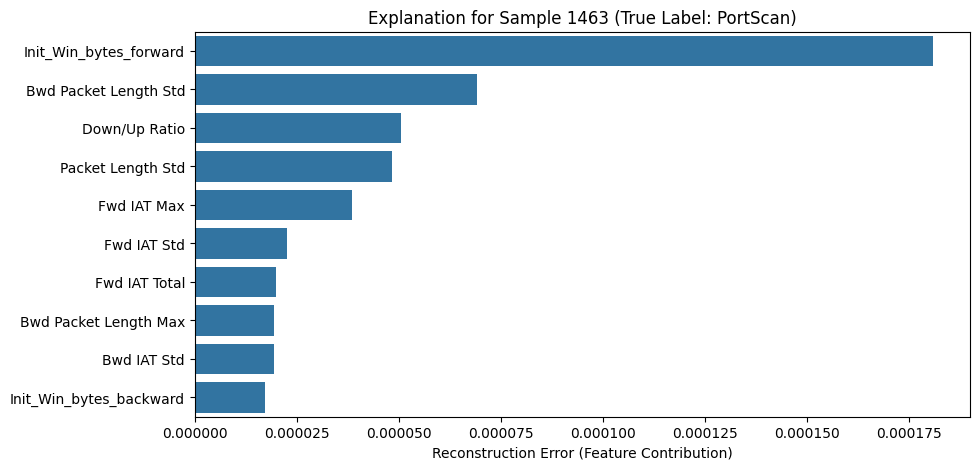

In [ ]:
# 3. Aspect créatif : Explicabilité des anomalies (XAI)
def explain_anomaly(idx, feature_names):
    sample = X_test_scaled[idx]
    actual_label = df['Label'].iloc[idx]
    recon = autoencoder_model.predict(sample.reshape(1, -1))
    
    # Calculer le MSE par feature
    mse_per_feature = np.power(sample - recon, 2).flatten()
    
    # Obtenir les 10 variables contributrices principales
    top_indices = np.argsort(mse_per_feature)[-10:][::-1]
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=mse_per_feature[top_indices], y=[feature_names[i] for i in top_indices])
    plt.title(f"Explication pour l'échantillon {idx} (Label réel : {actual_label})")
    plt.xlabel("Erreur de reconstruction (contribution par feature)")
    plt.show()

# Expliquer une anomalie aléatoire
anomaly_indices = np.where(np.array(y_true) == 1)[0]
if len(anomaly_indices) > 0:
    explain_anomaly(anomaly_indices[0], features)

 ## Interpretation des résultats:
 la décomposition par feature (MSE par feature) identifie les variables qui expliquent chaque anomalie — utile pour diagnostic métier et feature engineering.

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


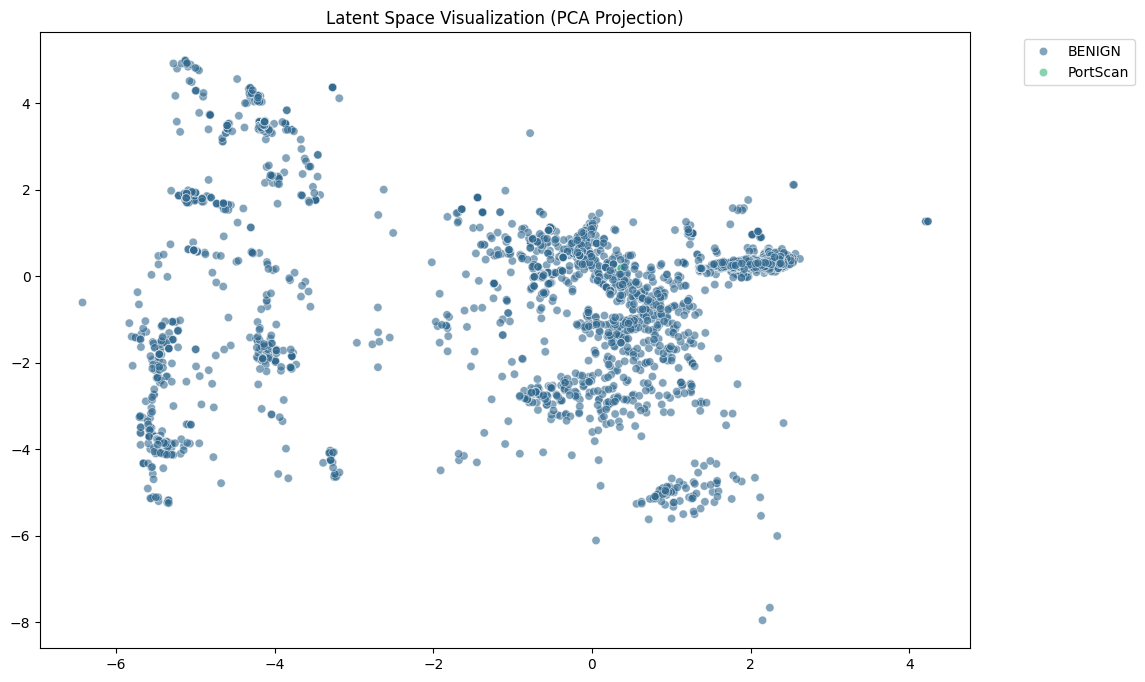

In [ ]:
# 4. Aspect créatif : Visualisation de l'espace latent
from sklearn.decomposition import PCA

# Obtenir les représentations latentes
latent_samples = encoder_model.predict(X_test_scaled[:5000])  # Échantillon pour la rapidité
labels_samples = df['Label'].iloc[:5000]

pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_samples)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=latent_2d[:, 0], y=latent_2d[:, 1], hue=labels_samples, palette='viridis', alpha=0.6)
plt.title("Visualisation de l'espace latent (projection PCA)")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

## Interpretation des résultats
BENIGN forme plusieurs grappes compactes centrées ; PortScan apparaît très rare et partiellement chevauché avec des points BENIGN. Globalement, séparation partielle mais recouvrements notables.

## Comparaison avec des modèles de référence
Dans cette section, nous comparons notre autoencodeur optimisé aux algorithmes classiques de détection d'anomalies : Isolation Forest et Local Outlier Factor (échantillonné).

In [ ]:
from sklearn.ensemble import IsolationForest
import time

# Échantillon de données pour accélérer l'entraînement des baselines si nécessaire
# X_train_scaled et X_test_scaled sont utilisés

results = {}

# --- 1. Isolation Forest ---
print("Entraînement d'Isolation Forest...")
start = time.time()
# 'contamination' correspond approximativement à la proportion attendue d'anomalies
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42, n_jobs=-1)
iso_forest.fit(X_train_scaled)
train_time_if = time.time() - start

# Prédiction (-1 = anomalie, 1 = normal)
if_preds = iso_forest.predict(X_test_scaled)
if_preds = [1 if x == -1 else 0 for x in if_preds]  # Convertir en 1=Anomalie, 0=Normal

results['Isolation Forest'] = {
    'f1': roc_auc_score(y_true, if_preds),  # Utilisation de l'AUC comme métrique de comparaison approximative
    'time': train_time_if,
    'report': classification_report(y_true, if_preds, output_dict=True)
}

# --- 2. Autoencoder (Notre modèle) ---
# 'y_pred_opt' est déjà disponible depuis les cellules précédentes
results['Optimized Autoencoder'] = {
    'f1': roc_auc_score(y_true, y_pred_opt),
    'time': 0,  # Le temps d'entraînement a été mesuré dans les cellules Optuna/entraînement final
    'report': classification_report(y_true, y_pred_opt, output_dict=True)
}

print("Évaluation des modèles de référence terminée.")

Training Isolation Forest...
Baselines evaluation complete.


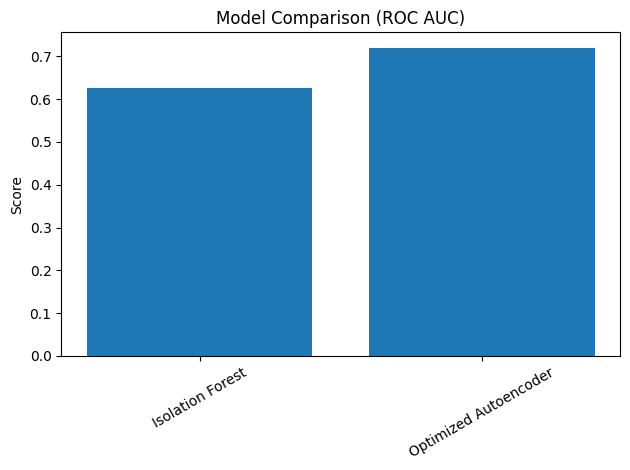

In [44]:
import matplotlib.pyplot as plt

# Extract data
models = list(results.keys())
scores = [results[m]['f1'] for m in models]
times = [results[m]['time'] for m in models]

# --- 1. AUC Comparison ---
plt.figure()
plt.bar(models, scores)
plt.title("Model Comparison (ROC AUC)")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Interprétation des résultats
Optimized Autoencoder (0.72 AUC) surpasse Isolation Forest (0.62 AUC) d’environ 0.10 — indication claire que l’autoencodeur sépare mieux anomalies vs normal sur les données utilisées.